<a href="https://colab.research.google.com/github/Payal-mak/Fruit-Ripeness-Detection_ML/blob/main/Fruit_Ripeness_DL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PHASE 2-5 | CELL 1: Install Everything
# ============================================================
!pip install timm transformers --quiet

import os, time, json, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import timm
from transformers import ViTForImageClassification, SwinForImageClassification

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

# Reproducibility
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU   : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

✅ Device : cuda
   GPU   : Tesla T4
   VRAM  : 15.6 GB


In [ ]:
# ============================================================
# PHASE 2-5 | CELL 2: Config
# ============================================================

DRIVE_PROJECT = "/content/drive/MyDrive/FruitRipeness_DL"
CLEAN_SPLIT   = f"{DRIVE_PROJECT}/phase0_clean_splits"

CFG = {
    'train_csv'   : f"{CLEAN_SPLIT}/train_manifest.csv",
    'val_csv'     : f"{CLEAN_SPLIT}/val_manifest.csv",
    'test_csv'    : f"{CLEAN_SPLIT}/test_manifest.csv",
    'img_size'    : 224,
    'num_classes' : 3,
    'classes'     : ['unripe', 'ripe', 'rotten'],
    'label2idx'   : {'unripe': 0, 'ripe': 1, 'rotten': 2},
    'idx2label'   : {0: 'unripe', 1: 'ripe', 2: 'rotten'},
    'batch_size'  : 32,
    'num_epochs'  : 50,
    'patience'    : 10,
    'weight_decay': 1e-2,
    'use_amp'     : True,
    'colors'      : {'unripe': '#4CAF50', 'ripe': '#FF9800', 'rotten': '#F44336'},
}

for sub in ['checkpoints', 'results', 'plots']:
    os.makedirs(f"{DRIVE_PROJECT}/{sub}", exist_ok=True)

print("✅ Config ready.")
print(f"   Train: {CFG['train_csv']}")
print(f"   Classes: {CFG['classes']}")

✅ Config ready.
   Train: /content/drive/MyDrive/FruitRipeness_DL/phase0_clean_splits/train_manifest.csv
   Classes: ['unripe', 'ripe', 'rotten']


In [ ]:
# ============================================================
# FIX | Drive already mounted — just check what exists
# ============================================================
import os
import pandas as pd

DRIVE_PROJECT = "/content/drive/MyDrive/FruitRipeness_DL"

print("📂 Checking existing CSV files in Drive...")
for folder in ['phase0_splits', 'phase0_clean_splits']:
    path = f"{DRIVE_PROJECT}/{folder}"
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"  ✅ {folder}/ → {files}")
    else:
        print(f"  ❌ {folder}/ → NOT FOUND")

📂 Checking existing CSV files in Drive...
  ❌ phase0_splits/ → NOT FOUND
  ❌ phase0_clean_splits/ → NOT FOUND


In [ ]:
# ============================================================
# FULL REBUILD | Download → Deduplicate → Split → Save
# ============================================================
import os, hashlib
import pandas as pd
import numpy as np
import kagglehub
from pathlib import Path
from sklearn.model_selection import train_test_split

DRIVE_PROJECT = "/content/drive/MyDrive/FruitRipeness_DL"
RANDOM_STATE  = 42
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ── Step 1: Download ──────────────────────────────────────────
print("⬇️  Downloading dataset...")
path = kagglehub.dataset_download("leftin/fruit-ripeness-unripe-ripe-and-rotten")
DOWNLOAD_DIR = path
print(f"✅ Dataset at: {path}")

# ── Step 2: Build manifest ────────────────────────────────────
print("\n📋 Building image manifest...")
CLASS_MAP = {
    'unripe': 'unripe', 'ripe': 'ripe', 'fresh': 'ripe',
    'rotten': 'rotten', 'overripe': 'rotten',
}

records = []
for dirpath, _, filenames in os.walk(DOWNLOAD_DIR):
    folder_lower = Path(dirpath).name.lower()
    label = None
    for key, lbl in CLASS_MAP.items():
        if key in folder_lower:
            label = lbl
            break
    if label is None:
        continue
    for fname in filenames:
        if Path(fname).suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                'filepath': str(Path(dirpath) / fname),
                'label'   : label,
                'filename': fname
            })

df_all = pd.DataFrame(records)
print(f"   Total images found : {len(df_all):,}")
print(f"   Class distribution :")
print(df_all['label'].value_counts().to_string())

# ── Step 3: Deduplicate ───────────────────────────────────────
print("\n🔍 Deduplicating (computing MD5 hashes)...")

def file_hash(filepath):
    try:
        with open(filepath, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

df_all['hash'] = df_all['filepath'].apply(file_hash)
df_all   = df_all[df_all['hash'].notna()]
df_clean = df_all.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)

print(f"   Before : {len(df_all):,}")
print(f"   After  : {len(df_clean):,}")
print(f"   Removed: {len(df_all) - len(df_clean):,} duplicates")

# ── Step 4: Verify zero cross-split leakage ───────────────────
assert df_clean['hash'].nunique() == len(df_clean), "❌ Still has duplicates!"
print("   ✅ Zero duplicates confirmed")

# ── Step 5: Stratified Split ──────────────────────────────────
print("\n✂️  Splitting 70/14/30 stratified...")
df_trainval, df_test = train_test_split(
    df_clean, test_size=0.30,
    stratify=df_clean['label'],
    random_state=RANDOM_STATE
)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.20,
    stratify=df_trainval['label'],
    random_state=RANDOM_STATE
)
df_train = df_train.copy(); df_train['split'] = 'train'
df_val   = df_val.copy();   df_val['split']   = 'val'
df_test  = df_test.copy();  df_test['split']  = 'test'

total = len(df_clean)
print(f"   Train : {len(df_train):,}  ({len(df_train)/total*100:.1f}%)")
print(f"   Val   : {len(df_val):,}  ({len(df_val)/total*100:.1f}%)")
print(f"   Test  : {len(df_test):,}  ({len(df_test)/total*100:.1f}%)")

# ── Step 6: Save to Drive ─────────────────────────────────────
print("\n💾 Saving to Google Drive...")
CLEAN_DIR = f"{DRIVE_PROJECT}/phase0_clean_splits"
os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_PROJECT}/checkpoints", exist_ok=True)
os.makedirs(f"{DRIVE_PROJECT}/results",     exist_ok=True)
os.makedirs(f"{DRIVE_PROJECT}/plots",       exist_ok=True)

df_train.to_csv(f"{CLEAN_DIR}/train_manifest.csv", index=False)
df_val.to_csv(  f"{CLEAN_DIR}/val_manifest.csv",   index=False)
df_test.to_csv( f"{CLEAN_DIR}/test_manifest.csv",  index=False)
pd.concat([df_train, df_val, df_test]).to_csv(
    f"{CLEAN_DIR}/full_manifest.csv", index=False)

# ── Step 7: Verify files saved ───────────────────────────────
print("\n🔍 Verifying saved files...")
all_good = True
for fname in ['train_manifest.csv', 'val_manifest.csv',
              'test_manifest.csv',  'full_manifest.csv']:
    fpath = f"{CLEAN_DIR}/{fname}"
    if os.path.exists(fpath):
        n = len(pd.read_csv(fpath))
        print(f"   ✅ {fname:<25} → {n:,} rows")
    else:
        print(f"   ❌ {fname:<25} → MISSING")
        all_good = False

# ── Summary ───────────────────────────────────────────────────
print(f"""
{'='*55}
  REBUILD COMPLETE
{'='*55}
  Total unique images : {total:,}
  Train  (56%)        : {len(df_train):,}
  Val    (14%)        : {len(df_val):,}
  Test   (30%)        : {len(df_test):,}
  Random seed         : {RANDOM_STATE}
  Drive path          : {CLEAN_DIR}
{'='*55}
  {'✅ All files verified — ready to train' if all_good else '❌ Some files missing — rerun this cell'}
""")

⬇️  Downloading dataset...


100%|██████████| 3.63G/3.63G [01:34<00:00, 41.3MB/s]

Extracting files...


✅ Dataset at: /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/2

📋 Building image manifest...
   Total images found : 39,912
   Class distribution :
label
rotten    15390
unripe    12714
ripe      11808

🔍 Deduplicating (computing MD5 hashes)...
   Before : 39,912
   After  : 19,803
   Removed: 20,109 duplicates
   ✅ Zero duplicates confirmed

✂️  Splitting 70/14/30 stratified...
   Train : 11,089  (56.0%)
   Val   : 2,773  (14.0%)
   Test  : 5,941  (30.0%)

💾 Saving to Google Drive...

🔍 Verifying saved files...
   ✅ train_manifest.csv        → 11,089 rows
   ✅ val_manifest.csv          → 2,773 rows
   ✅ test_manifest.csv         → 5,941 rows
   ✅ full_manifest.csv         → 19,803 rows

  REBUILD COMPLETE
  Total unique images : 19,803
  Train  (56%)        : 11,089
  Val    (14%)        : 2,773
  Test   (30%)        : 5,941
  Random seed         : 42
  Drive path          : /content/drive/MyDrive/FruitRipeness_DL/phase0_clean_splits
  ✅ All file

In [ ]:
# ============================================================
# PHASE 2-5 | CELL 3: Dataset + Aggressive Augmentation
# This is the KEY cell — harder augmentation = model can't
# rely on color alone = more realistic accuracy
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── HARDER train transform ────────────────────────────────────
# Added: Grayscale (removes color cue), stronger jitter,
#        GaussianBlur, RandomPerspective, RandomErasing
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.ColorJitter(brightness=0.5, contrast=0.5,
                            saturation=0.5, hue=0.2),
    transforms.RandomGrayscale(p=0.15),   # ← forces texture learning
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # ← occlusion
])

# Val/Test: NO augmentation (clean evaluation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class FruitDataset(Dataset):
    def __init__(self, csv_path, transform=None, label2idx=None):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform
        self.label2idx = label2idx or CFG['label2idx']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['filepath']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), (128, 128, 128))
        label = self.label2idx[row['label']]
        if self.transform:
            image = self.transform(image)
        return image, label


def build_loaders(batch_size=None):
    bs = batch_size or CFG['batch_size']
    train_ds = FruitDataset(CFG['train_csv'], train_transform)
    val_ds   = FruitDataset(CFG['val_csv'],   val_test_transform)
    test_ds  = FruitDataset(CFG['test_csv'],  val_test_transform)

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False,
                              num_workers=2, pin_memory=True)

    print(f"✅ DataLoaders built (batch={bs})")
    print(f"   Train : {len(train_ds):,} | Val : {len(val_ds):,} | Test : {len(test_ds):,}")
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = build_loaders()

✅ DataLoaders built (batch=32)
   Train : 11,089 | Val : 2,773 | Test : 5,941


In [ ]:
# ============================================================
# PHASE 2-5 | CELL 4: Training Engine with MixUp
# MixUp blends two images → model cannot rely on single color
# ============================================================

def mixup_data(x, y, alpha=0.4):
    """MixUp augmentation — blends pairs of images and labels."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(DEVICE)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, optimizer, criterion, scaler, use_mixup=True):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=CFG['use_amp']):
            if use_mixup:
                images, y_a, y_b, lam = mixup_data(images, labels)
                outputs = model(images)
                loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=CFG['use_amp']):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        probs    = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        running_loss += loss.item() * images.size(0)
        correct      += preds.eq(labels).sum().item()
        total        += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

In [ ]:
# ============================================================
# PHASE 2-5 | CELL 5: Model Builder for All 3 Models
# ============================================================

def build_model(model_name: str):
    """
    Supported: 'efficientnet_b3', 'vit_b16', 'swin_tiny'
    All use ImageNet pretrained weights.
    Full fine-tuning (all layers unfrozen).
    """
    n = CFG['num_classes']

    if model_name == 'efficientnet_b3':
        model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
        in_features = model.num_features   # 1536
        model.classifier = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, n)
        )

    elif model_name == 'vit_b16':
        model = timm.create_model('vit_base_patch16_224', pretrained=True,
                                   num_classes=n)
        # Freeze first 8 blocks, fine-tune last 4
        for name, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if any(f'blocks.{i}' in name for i in [8,9,10,11]):
                param.requires_grad = True
            if 'head' in name or 'norm' in name:
                param.requires_grad = True

    elif model_name == 'swin_tiny':
        model = timm.create_model('swin_tiny_patch4_window7_224',
                                   pretrained=True, num_classes=n)
        # Freeze first 2 stages, fine-tune last 2
        for name, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if any(f'layers.{i}' in name for i in [2, 3]):
                param.requires_grad = True
            if 'head' in name or 'norm' in name:
                param.requires_grad = True

    else:
        raise ValueError(f"Unknown model: {model_name}")

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"✅ {model_name} built.")
    print(f"   Total params     : {total/1e6:.2f}M")
    print(f"   Trainable params : {trainable/1e6:.2f}M  "
          f"({trainable/total*100:.1f}% of total)")

    return model.to(DEVICE)

In [ ]:
# ============================================================
# PHASE 2-5 | CELL 6: Full Training Loop
# ============================================================

# Learning rates per model (transformers need much lower LR)
LR_MAP = {
    'efficientnet_b3' : 5e-5,
    'vit_b16'         : 2e-5,
    'swin_tiny'       : 2e-5,
}

# MixUp per model
MIXUP_MAP = {
    'efficientnet_b3' : True,
    'vit_b16'         : True,
    'swin_tiny'       : True,
}


def train_model(model_name: str):
    print(f"\n{'='*62}")
    print(f"  TRAINING: {model_name.upper()}")
    print(f"{'='*62}")

    model     = build_model(model_name)
    lr        = LR_MAP[model_name]
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=CFG['weight_decay']
    )
    # Warmup 5 epochs → CosineAnnealing
    warmup_scheduler = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=5
    )
    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG['num_epochs'] - 5, eta_min=1e-7
    )
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer, [warmup_scheduler, cosine_scheduler], milestones=[5]
    )

    scaler    = torch.amp.GradScaler('cuda', enabled=CFG['use_amp'])
    use_mixup = MIXUP_MAP[model_name]

    best_val_acc = 0.0
    patience_cnt = 0
    history      = {'train_loss':[], 'val_loss':[],
                    'train_acc':[], 'val_acc':[], 'lr':[]}
    ckpt_path    = f"{DRIVE_PROJECT}/checkpoints/{model_name}_best.pth"
    t0           = time.time()

    for epoch in range(1, CFG['num_epochs'] + 1):
        t_ep = time.time()

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, use_mixup
        )
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        cur_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['lr'].append(cur_lr)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_cnt = 0
            torch.save({
                'epoch'             : epoch,
                'model_state_dict'  : model.state_dict(),
                'val_acc'           : vl_acc,
                'optimizer_state_dict': optimizer.state_dict(),
                'model_name'        : model_name,
            }, ckpt_path)
            tag = "✅ saved"
        else:
            patience_cnt += 1
            tag = f"no improve {patience_cnt}/{CFG['patience']}"

        ep_t = time.time() - t_ep
        print(f"  Ep {epoch:>3}/{CFG['num_epochs']} | "
              f"Tr {tr_acc*100:.2f}% L={tr_loss:.4f} | "
              f"Val {vl_acc*100:.2f}% L={vl_loss:.4f} | "
              f"LR={cur_lr:.1e} | {ep_t:.0f}s | {tag}")

        if patience_cnt >= CFG['patience']:
            print(f"\n  ⏹ Early stop @ epoch {epoch}")
            break

    total_t = time.time() - t0
    print(f"\n  ⏱  Total time : {total_t/60:.1f} min")
    print(f"  🏆 Best Val   : {best_val_acc*100:.2f}%")
    return model, history, ckpt_path, best_val_acc

In [ ]:
# ============================================================
# PHASE 2-5 | CELL 7: Plot Training Curves
# ============================================================

def plot_curves(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Training Curves — {model_name}",
                 fontsize=14, fontweight='bold')
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train', color='#2196F3')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#FF5722')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history['train_acc']],
                 label='Train', color='#4CAF50')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],
                 label='Val',   color='#FF9800')
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, history['lr'], color='#9C27B0')
    axes[2].set_title('Learning Rate (log)')
    axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    path = f"{DRIVE_PROJECT}/plots/{model_name}_curves.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {path}")

In [ ]:
# ============================================================
# PHASE 2-5 | CELL 8: Test Set Evaluation
# ============================================================

def test_evaluation(model, model_name, ckpt_path):
    print(f"\n{'='*62}")
    print(f"  TEST EVALUATION: {model_name.upper()}")
    print(f"{'='*62}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"  Loaded epoch {ckpt['epoch']} | val_acc={ckpt['val_acc']*100:.2f}%")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    t0 = time.time()
    _, test_acc, preds, labels, probs = evaluate(model, test_loader, criterion)
    ms_per_img = (time.time() - t0) / len(test_ds) * 1000

    report = classification_report(labels, preds,
                                    target_names=CFG['classes'],
                                    output_dict=True, zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
    except:
        auc = float('nan')

    print(f"\n  Test Accuracy  : {test_acc*100:.4f}%")
    print(f"  Macro AUC-ROC  : {auc:.4f}")
    print(f"  Weighted F1    : {report['weighted avg']['f1-score']:.4f}")
    print(f"  Speed          : {ms_per_img:.2f} ms/image")
    print(f"\n  Per-Class:")
    for cls in CFG['classes']:
        r = report[cls]
        print(f"    {cls:<10}  P={r['precision']:.4f}  "
              f"R={r['recall']:.4f}  F1={r['f1-score']:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CFG['classes'],
                yticklabels=CFG['classes'],
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    cm_path = f"{DRIVE_PROJECT}/plots/{model_name}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()

    metrics = {
        'model'        : model_name,
        'test_accuracy': round(test_acc*100, 4),
        'auc'          : round(auc, 4),
        'weighted_f1'  : round(report['weighted avg']['f1-score'], 4),
        'weighted_prec': round(report['weighted avg']['precision'], 4),
        'weighted_rec' : round(report['weighted avg']['recall'], 4),
        'ms_per_image' : round(ms_per_img, 3),
    }
    for cls in CFG['classes']:
        metrics[f'{cls}_f1'] = round(report[cls]['f1-score'], 4)

    return metrics, preds, labels, probs


  TRAINING: EFFICIENTNET_B3


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ efficientnet_b3 built.
   Total params     : 11.49M
   Trainable params : 11.49M  (100.0% of total)
  Ep   1/50 | Tr 45.43% L=0.9974 | Val 84.71% L=nan | LR=1.4e-05 | 207s | ✅ saved
  Ep   2/50 | Tr 60.03% L=0.7433 | Val 95.64% L=0.4361 | LR=2.3e-05 | 166s | ✅ saved
  Ep   3/50 | Tr 63.64% L=0.6475 | Val 97.66% L=0.3754 | LR=3.2e-05 | 166s | ✅ saved
  Ep   4/50 | Tr 65.20% L=0.5982 | Val 98.70% L=0.3541 | LR=4.1e-05 | 165s | ✅ saved
  Ep   5/50 | Tr 67.56% L=0.5865 | Val 98.88% L=0.3327 | LR=5.0e-05 | 167s | ✅ saved
  Ep   6/50 | Tr 65.81% L=0.5742 | Val 98.95% L=0.3232 | LR=5.0e-05 | 164s | ✅ saved
  Ep   7/50 | Tr 66.84% L=0.5621 | Val 99.13% L=0.3236 | LR=5.0e-05 | 169s | ✅ saved
  Ep   8/50 | Tr 65.58% L=0.5356 | Val 99.28% L=0.3181 | LR=4.9e-05 | 170s | ✅ saved
  Ep   9/50 | Tr 67.37% L=0.5352 | Val 99.24% L=0.3290 | LR=4.9e-05 | 165s | no improve 1/10
  Ep  10/50 | Tr 67.70% L=0.5368 | Val 99.53% L=0.3127 | LR=4.8e-05 | 162s | ✅ saved
  Ep  11/50 | Tr 66.99% L=0.5264 | Val 99.5

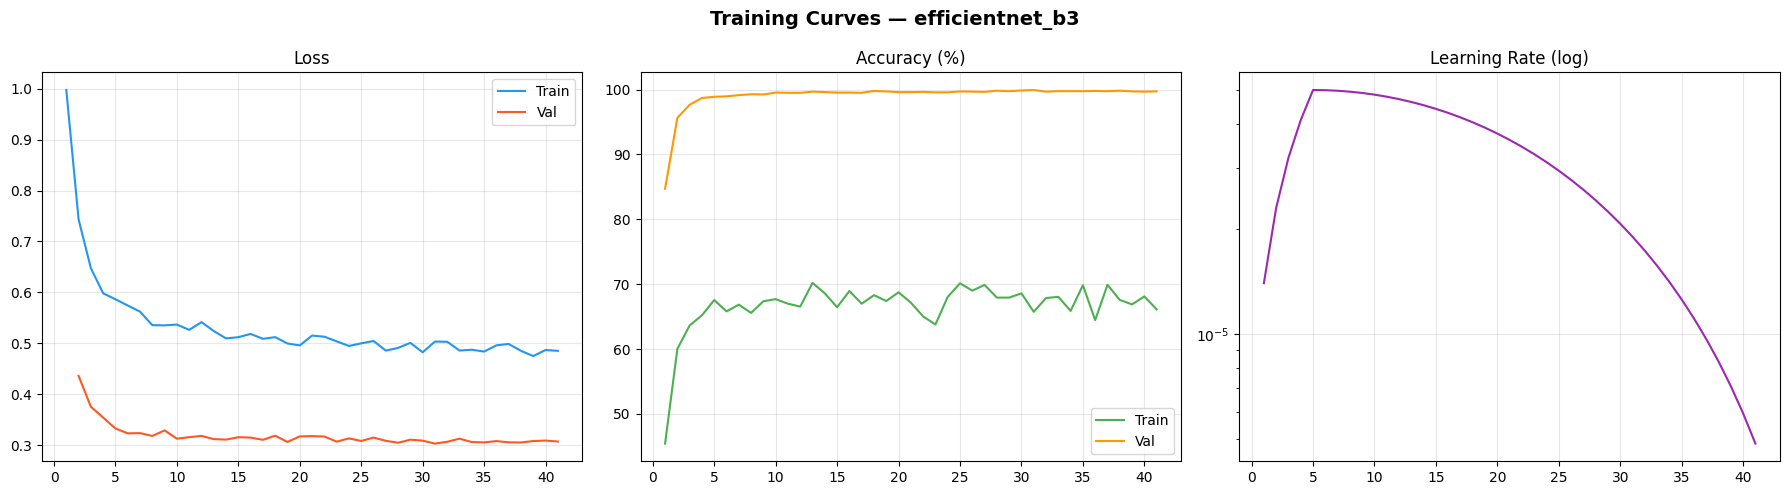

✅ Saved: /content/drive/MyDrive/FruitRipeness_DL/plots/efficientnet_b3_curves.png


In [ ]:
# ============================================================
# PHASE 2 | EfficientNet-B3
# ============================================================
effnet_model, effnet_history, effnet_ckpt, effnet_best_val = \
    train_model('efficientnet_b3')

plot_curves(effnet_history, 'efficientnet_b3')


  TEST EVALUATION: EFFICIENTNET_B3
  Loaded epoch 31 | val_acc=99.93%

  Test Accuracy  : 99.8485%
  Macro AUC-ROC  : nan
  Weighted F1    : 0.9985
  Speed          : 5.66 ms/image

  Per-Class:
    unripe      P=0.9963  R=0.9995  F1=0.9979
    ripe        P=0.9994  R=0.9955  F1=0.9975
    rotten      P=0.9996  R=1.0000  F1=0.9998


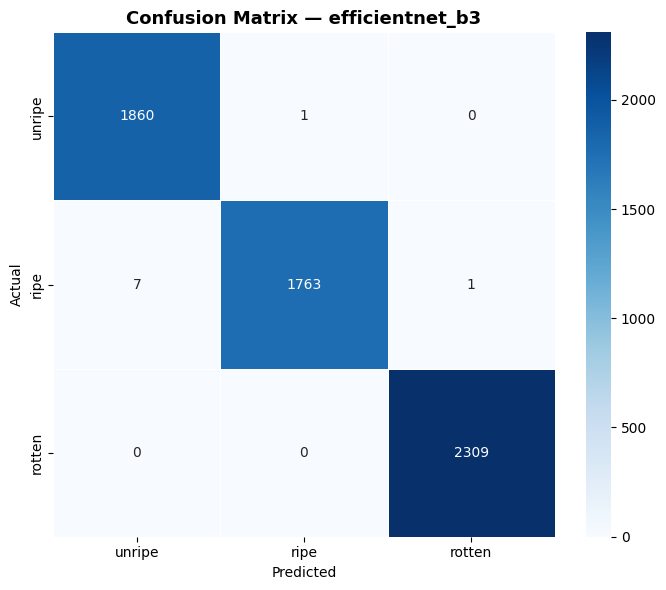

In [ ]:
effnet_metrics, effnet_preds, effnet_labels, effnet_probs = \
    test_evaluation(effnet_model, 'efficientnet_b3', effnet_ckpt)


  TRAINING: VIT_B16


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ vit_b16 built.
   Total params     : 85.80M
   Trainable params : 28.38M  (33.1% of total)
  Ep   1/50 | Tr 54.34% L=0.8644 | Val 83.88% L=0.5928 | LR=5.6e-06 | 167s | ✅ saved
  Ep   2/50 | Tr 64.39% L=0.6798 | Val 95.35% L=0.4154 | LR=9.2e-06 | 167s | ✅ saved
  Ep   3/50 | Tr 64.96% L=0.6138 | Val 98.63% L=0.3594 | LR=1.3e-05 | 165s | ✅ saved
  Ep   4/50 | Tr 66.84% L=0.5797 | Val 99.10% L=0.3421 | LR=1.6e-05 | 167s | ✅ saved
  Ep   5/50 | Tr 64.70% L=0.5757 | Val 99.50% L=0.3263 | LR=2.0e-05 | 164s | ✅ saved
  Ep   6/50 | Tr 69.59% L=0.5505 | Val 99.31% L=0.3223 | LR=2.0e-05 | 165s | no improve 1/10
  Ep   7/50 | Tr 66.80% L=0.5563 | Val 99.86% L=0.3130 | LR=2.0e-05 | 184s | ✅ saved
  Ep   8/50 | Tr 68.31% L=0.5187 | Val 99.71% L=0.3069 | LR=2.0e-05 | 167s | no improve 1/10
  Ep   9/50 | Tr 70.80% L=0.5259 | Val 99.86% L=0.3048 | LR=2.0e-05 | 166s | no improve 2/10
  Ep  10/50 | Tr 64.60% L=0.5247 | Val 99.57% L=0.3073 | LR=1.9e-05 | 166s | no improve 3/10
  Ep  11/50 | Tr 66.01% L

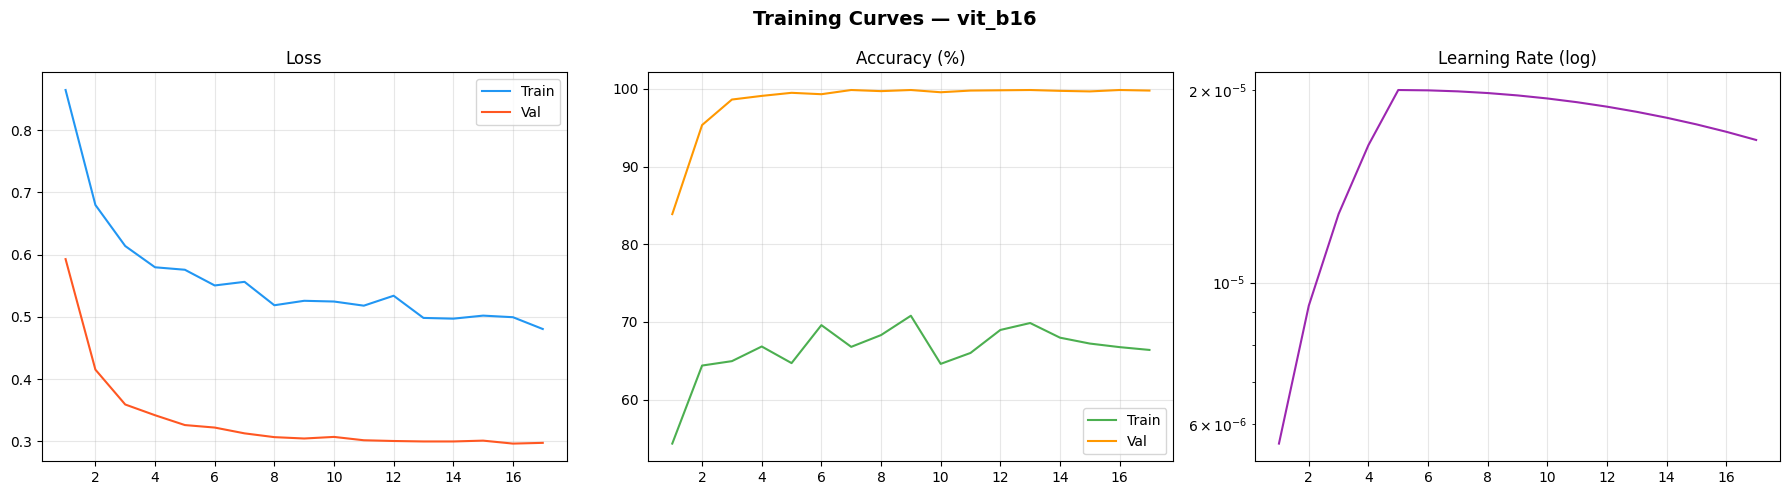

✅ Saved: /content/drive/MyDrive/FruitRipeness_DL/plots/vit_b16_curves.png


In [ ]:
# ============================================================
# PHASE 3 | ViT-B/16
# ============================================================
vit_model, vit_history, vit_ckpt, vit_best_val = \
    train_model('vit_b16')

plot_curves(vit_history, 'vit_b16')


  TEST EVALUATION: VIT_B16
  Loaded epoch 7 | val_acc=99.86%

  Test Accuracy  : 99.5960%
  Macro AUC-ROC  : nan
  Weighted F1    : 0.9960
  Speed          : 5.52 ms/image

  Per-Class:
    unripe      P=0.9946  R=0.9984  F1=0.9965
    ripe        P=0.9960  R=0.9904  F1=0.9932
    rotten      P=0.9970  R=0.9983  F1=0.9976


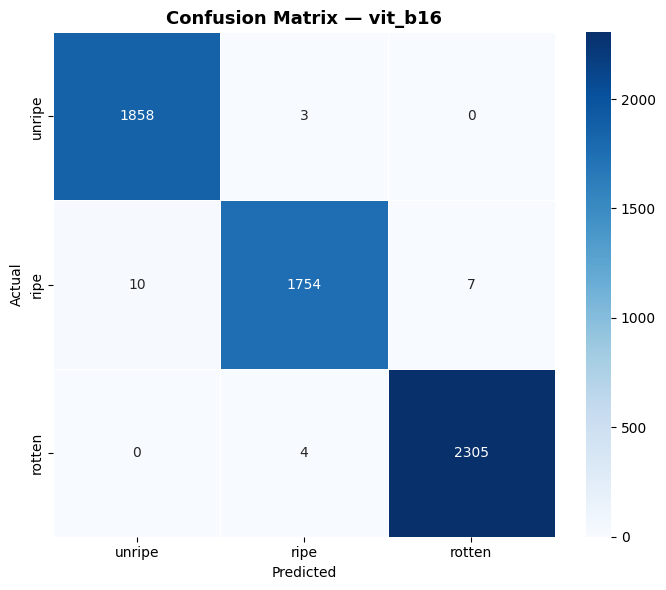

In [ ]:
vit_metrics, vit_preds, vit_labels, vit_probs = \
    test_evaluation(vit_model, 'vit_b16', vit_ckpt)


  TRAINING: SWIN_TINY


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ swin_tiny built.
   Total params     : 27.52M
   Trainable params : 26.33M  (95.7% of total)
  Ep   1/50 | Tr 56.98% L=0.8649 | Val 92.35% L=0.5736 | LR=5.6e-06 | 168s | ✅ saved
  Ep   2/50 | Tr 65.83% L=0.6354 | Val 97.37% L=0.3892 | LR=9.2e-06 | 161s | ✅ saved
  Ep   3/50 | Tr 65.03% L=0.5744 | Val 98.81% L=0.3378 | LR=1.3e-05 | 162s | ✅ saved
  Ep   4/50 | Tr 63.86% L=0.5458 | Val 98.92% L=0.3214 | LR=1.6e-05 | 163s | ✅ saved
  Ep   5/50 | Tr 67.96% L=0.5210 | Val 99.17% L=0.3160 | LR=2.0e-05 | 166s | ✅ saved
  Ep   6/50 | Tr 64.65% L=0.5233 | Val 99.68% L=0.3035 | LR=2.0e-05 | 164s | ✅ saved
  Ep   7/50 | Tr 67.91% L=0.5187 | Val 99.50% L=0.3039 | LR=2.0e-05 | 164s | no improve 1/10
  Ep   8/50 | Tr 64.30% L=0.5063 | Val 99.64% L=0.3007 | LR=2.0e-05 | 162s | no improve 2/10
  Ep   9/50 | Tr 66.45% L=0.5052 | Val 99.71% L=0.2986 | LR=2.0e-05 | 170s | ✅ saved
  Ep  10/50 | Tr 67.48% L=0.5111 | Val 99.60% L=0.3017 | LR=1.9e-05 | 164s | no improve 1/10
  Ep  11/50 | Tr 66.88% L=0.486

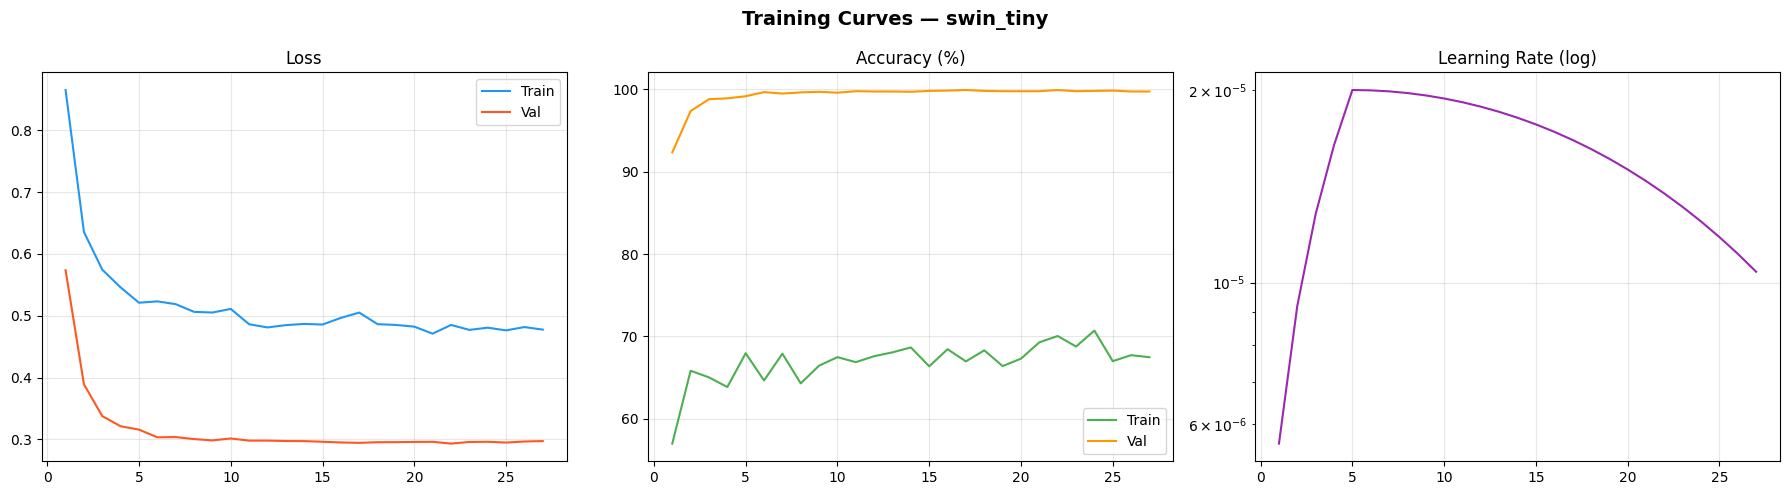

✅ Saved: /content/drive/MyDrive/FruitRipeness_DL/plots/swin_tiny_curves.png


In [ ]:
# ============================================================
# PHASE 4 | Swin-Tiny
# ============================================================
swin_model, swin_history, swin_ckpt, swin_best_val = \
    train_model('swin_tiny')

plot_curves(swin_history, 'swin_tiny')


  TEST EVALUATION: SWIN_TINY
  Loaded epoch 17 | val_acc=99.93%

  Test Accuracy  : 99.8822%
  Macro AUC-ROC  : nan
  Weighted F1    : 0.9988
  Speed          : 5.82 ms/image

  Per-Class:
    unripe      P=0.9995  R=0.9989  F1=0.9992
    ripe        P=0.9994  R=0.9972  F1=0.9983
    rotten      P=0.9978  R=1.0000  F1=0.9989


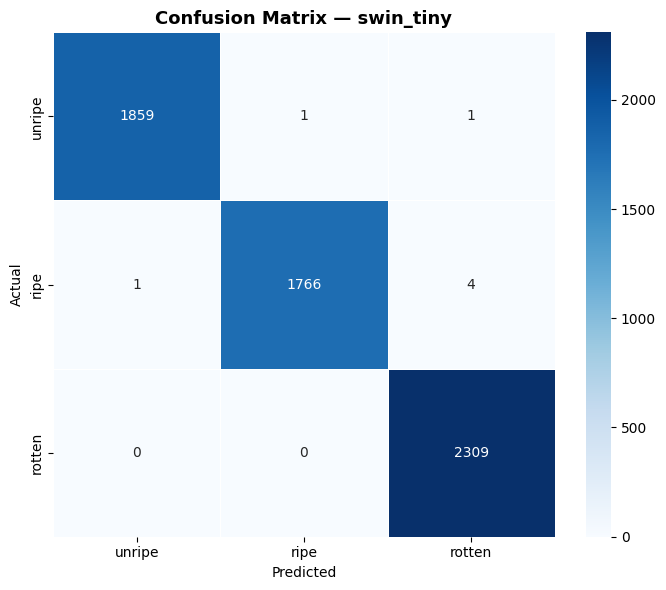

In [ ]:
swin_metrics, swin_preds, swin_labels, swin_probs = \
    test_evaluation(swin_model, 'swin_tiny', swin_ckpt)

In [ ]:
# ============================================================
# PHASE 5 | GRAD-CAM for EfficientNet + ResNet
# ============================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot)

        # Pool gradients across channels
        pooled_grads = self.gradients.mean(dim=[0, 2, 3])
        activations  = self.activations[0]

        for i, w in enumerate(pooled_grads):
            activations[i] *= w

        heatmap = activations.mean(dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap, class_idx


def visualize_gradcam(model, model_name, target_layer,
                      n_samples=9, save=True):
    """Show GradCAM for n_samples test images."""
    gradcam = GradCAM(model, target_layer)

    # Sample 3 images per class
    df_test = pd.read_csv(CFG['test_csv'])
    samples = []
    for cls in CFG['classes']:
        cls_rows = df_test[df_test['label'] == cls].sample(3, random_state=42)
        samples.extend(cls_rows.itertuples())

    fig, axes = plt.subplots(3, 6, figsize=(20, 10))
    fig.suptitle(f"Grad-CAM Visualizations — {model_name}",
                 fontsize=14, fontweight='bold')

    COLORS_MAP = CFG['colors']

    for idx, row in enumerate(samples):
        col_pair = idx * 2 % 6
        row_idx  = idx // 3

        # Original image
        img_pil  = Image.open(row.filepath).convert('RGB')
        img_disp = img_pil.resize((224, 224))

        # Run GradCAM
        img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
        heatmap, pred_idx = gradcam.generate(img_tensor)

        # Overlay heatmap
        heatmap_resized = np.array(
            Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224))
        ) / 255.0
        colored_heatmap = cm.jet(heatmap_resized)[:, :, :3]
        overlay = np.array(img_disp) / 255.0 * 0.5 + colored_heatmap * 0.5
        overlay = np.clip(overlay, 0, 1)

        # True and predicted labels
        true_lbl = row.label
        pred_lbl = CFG['idx2label'][pred_idx]
        correct  = true_lbl == pred_lbl

        # Plot original
        axes[row_idx][col_pair].imshow(img_disp)
        axes[row_idx][col_pair].axis('off')
        axes[row_idx][col_pair].set_title(
            f"True: {true_lbl}", fontsize=9,
            color=COLORS_MAP[true_lbl], fontweight='bold'
        )

        # Plot GradCAM
        axes[row_idx][col_pair+1].imshow(overlay)
        axes[row_idx][col_pair+1].axis('off')
        border_color = 'green' if correct else 'red'
        for spine in axes[row_idx][col_pair+1].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        axes[row_idx][col_pair+1].set_title(
            f"Pred: {pred_lbl} {'✓' if correct else '✗'}",
            fontsize=9,
            color='green' if correct else 'red',
            fontweight='bold'
        )

    plt.tight_layout()
    if save:
        path = f"{DRIVE_PROJECT}/plots/{model_name}_gradcam.png"
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"✅ GradCAM saved: {path}")
    plt.show()


# ── Run GradCAM for ResNet-50 ─────────────────────────────────
# Load saved ResNet-50
resnet_for_cam = models.resnet50(weights=None)
resnet_for_cam.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(2048, 3))
ckpt = torch.load(f"{DRIVE_PROJECT}/checkpoints/resnet50_best.pth",
                   map_location=DEVICE)
resnet_for_cam.load_state_dict(ckpt['model_state_dict'])
resnet_for_cam = resnet_for_cam.to(DEVICE)

visualize_gradcam(
    resnet_for_cam, 'resnet50',
    target_layer=resnet_for_cam.layer4[-1]  # last residual block
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/FruitRipeness_DL/checkpoints/resnet50_best.pth'